# Precipitation Nowcasting Baseline

## Task Description
Given **3 consecutive satellite observation images** (captured at 10-minute intervals over the last 30 minutes), predict the **GPM IMERG precipitation map** at the next 30-minute mark.

### Data Summary
| Property | Satellite Input (Himawari/Meteosat/GOES) | Target (GPM IMERG) |
|----------|------------------------------------------|-----------|
| Format | GeoTIFF, uint8 | GeoTIFF, float32 |
| Bands | 16 (we use first 3 only) | 1 |
| Spatial | 81×81 (Himawari) / 144×144 (Meteosat) / 141×141 (GOES) | 41×41 |
| Files/sample | 3 TIFs (temporal sequence) | 1 TIF |

### This Notebook
An end-to-end baseline that covers:
1. **Data Exploration** — inspect the dataset structure and sample files
2. **Dataset Class** — PyTorch Dataset for loading and preprocessing
3. **Model Definition** — SimpleCNN for image-to-image regression
4. **Training** — train the model with MSE loss
5. **Inference & Submission** — generate predictions and package for upload

### Expected Directory Structure
The dataset ZIP files are already extracted. The working directory should look like this:
```
working_dir/
├── baseline_notebook.ipynb        ← this notebook
├── train_dataset/
│   ├── train_dataset.csv
│   ├── himawari/
│   ├── meteosat/
│   ├── goes/
│   └── gpm_imerg/
└── evaluation_dataset/
    ├── evaluation_target.csv
    ├── himawari/
    ├── meteosat/
    ├── goes/
    └── test_files/
```

In [1]:
import os
from pathlib import Path

# --- Locate Workspace and Verify Extracted Datasets ---
# Works whether the kernel starts in the workspace root or in src/.
candidates = [Path.cwd(), Path.cwd().parent]
workspace_root = next(
    (path for path in candidates
     if (path / 'train_dataset').is_dir()
     and (path / 'evaluation_dataset').is_dir()),
    None,
)
if workspace_root is None:
    raise FileNotFoundError('train_dataset/ and evaluation_dataset/ were not found.')

os.chdir(workspace_root)
print(f'  ✓ Workspace: {workspace_root}')
print('  ✓ train_dataset/ found')
print('  ✓ evaluation_dataset/ found')

  ✓ Workspace: /Users/shionsuio/solafune-workspace
  ✓ train_dataset/ found
  ✓ evaluation_dataset/ found


---
## 1. Imports & Configuration

In [2]:
import os
import ast
import json
import time
import shutil
import zipfile
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

PyTorch version: 2.12.1
CUDA available: False
Device: mps


In [3]:
# --- Configuration ---
# Paths relative to this notebook. Adjust if your directory structure differs.

TRAIN_DIR = 'train_dataset'
TEST_DIR = 'evaluation_dataset'

TRAIN_CSV = os.path.join(TRAIN_DIR, 'train_dataset.csv')
EVAL_TARGET_CSV = os.path.join(TEST_DIR, 'evaluation_target.csv')

# Satellite data folders
SATELLITE_DIRS = {
    'himawari': {'train': os.path.join(TRAIN_DIR, 'himawari'), 'test': os.path.join(TEST_DIR, 'himawari')},
    'meteosat': {'train': os.path.join(TRAIN_DIR, 'meteosat'), 'test': os.path.join(TEST_DIR, 'meteosat')},
    'goes':     {'train': os.path.join(TRAIN_DIR, 'goes'),     'test': os.path.join(TEST_DIR, 'goes')},
}

# Target data folder (training only — GPM IMERG precipitation maps)
GPM_TRAIN_DIR = os.path.join(TRAIN_DIR, 'gpm_imerg')

# Output directories
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Hyperparameters
TARGET_SIZE = (41, 41)
NUM_BANDS = 3
MAX_OBS = 3
INPUT_CHANNELS = NUM_BANDS * MAX_OBS  # 9
OUTPUT_CHANNELS = 1
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
EPOCHS = 20

# Verify paths
for name, path in [('Train CSV', TRAIN_CSV), ('Eval CSV', EVAL_TARGET_CSV), ('GPM Train', GPM_TRAIN_DIR)]:
    status = '✓' if os.path.exists(path) else '✗'
    print(f'  {status} {name}')
for sat_name, dirs in SATELLITE_DIRS.items():
    for split, path in dirs.items():
        status = '✓' if os.path.exists(path) else '✗'
        print(f'  {status} {sat_name}/{split}')

  ✓ Train CSV
  ✓ Eval CSV
  ✓ GPM Train
  ✓ himawari/train
  ✓ himawari/test
  ✓ meteosat/train
  ✓ meteosat/test
  ✓ goes/train
  ✓ goes/test


---
## 2. Data Exploration

In [4]:
# --- Load Training Metadata ---

train_df = pd.read_csv(TRAIN_CSV)
print(f'Training samples: {len(train_df):,}')
print(f'Columns: {list(train_df.columns)}')
print(f'\nUnique locations: {sorted(train_df["name_location"].unique())}')
print(f'Unique satellites: {sorted(train_df["satellite_target"].unique())}')
print(f'\nSamples per satellite:')
print(train_df.groupby('satellite_target').size())
train_df.head()

Training samples: 40,686
Columns: ['unique_id', 'name_location', 'satellite_target', 'datetime', 'last_30_minutes_observation_filename', 'gpm_imerg_filename']

Unique locations: ['aceh', 'andalusia', 'atlantic_coast', 'bahia_blanca', 'bihar', 'borno_state', 'cape_town', 'central_philippines', 'central_vietnam', 'dhaka', 'ecuador', 'florida', 'france', 'friuli_venezia_giulia', 'gaza_province', 'guangdong', 'hat_yai', 'jakarta', 'jamaica', 'kinshasa']
Unique satellites: ['goes', 'himawari', 'meteosat']

Samples per satellite:
satellite_target
goes        10272
himawari    13192
meteosat    17222
dtype: int64


,unique_id,name_location,satellite_target,datetime,last_30_minutes_observation_filename,gpm_imerg_filename
0,c901-207d,aceh,himawari,2023-01-01 00:00:00,"['train_aceh_Himawari_20221231_2330.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-00-00.tif
1,3311-9497,aceh,himawari,2023-01-01 00:30:00,"['train_aceh_Himawari_20230101_0000.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_00-30-00.tif
2,ae46-e82d,aceh,himawari,2023-01-01 01:00:00,"['train_aceh_Himawari_20230101_0030.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_01-00-00.tif
3,6ca6-b8d8,aceh,himawari,2023-01-01 01:30:00,"['train_aceh_Himawari_20230101_0100.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_01-30-00.tif
4,20a1-eba0,aceh,himawari,2023-01-01 02:00:00,"['train_aceh_Himawari_20230101_0130.tif', 'tra...",train_aceh_GPM_IMERG_2023-01-01_02-00-00.tif


In [5]:
# --- Inspect Satellite TIF Properties ---

import glob

for sat_name in SATELLITE_DIRS:
    sat_dir = SATELLITE_DIRS[sat_name]['train']
    tif_files = sorted(glob.glob(os.path.join(sat_dir, '*.tif')))
    if not tif_files:
        print(f'{sat_name.upper()}: no TIF files found')
        continue
    with rasterio.open(tif_files[0]) as src:
        data = src.read()
        print(f'{sat_name.upper()}: {src.count} bands, {src.width}×{src.height}, '
              f'dtype={src.dtypes[0]}, bands 1-3 range=[{data[:3].min()}, {data[:3].max()}]')

HIMAWARI: 16 bands, 81×81, dtype=uint8, bands 1-3 range=[1, 14]
METEOSAT: 16 bands, 144×144, dtype=uint8, bands 1-3 range=[0, 2]
GOES: 16 bands, 141×141, dtype=uint8, bands 1-3 range=[3, 123]


In [6]:
# --- Inspect GPM IMERG Target ---

gpm_files = sorted(glob.glob(os.path.join(GPM_TRAIN_DIR, '*.tif')))
print(f'Total GPM IMERG training files: {len(gpm_files):,}')

with rasterio.open(gpm_files[0]) as src:
    gpm_data = src.read(1)
    print(f'GPM IMERG: {src.count} band, {src.width}×{src.height}, dtype={src.dtypes[0]}')
    print(f'  Value range: [{gpm_data.min():.4f}, {gpm_data.max():.4f}], '
          f'mean={gpm_data.mean():.4f}')

Total GPM IMERG training files: 40,686
GPM IMERG: 1 band, 41×41, dtype=float32
  Value range: [0.0260, 0.8530], mean=0.3633


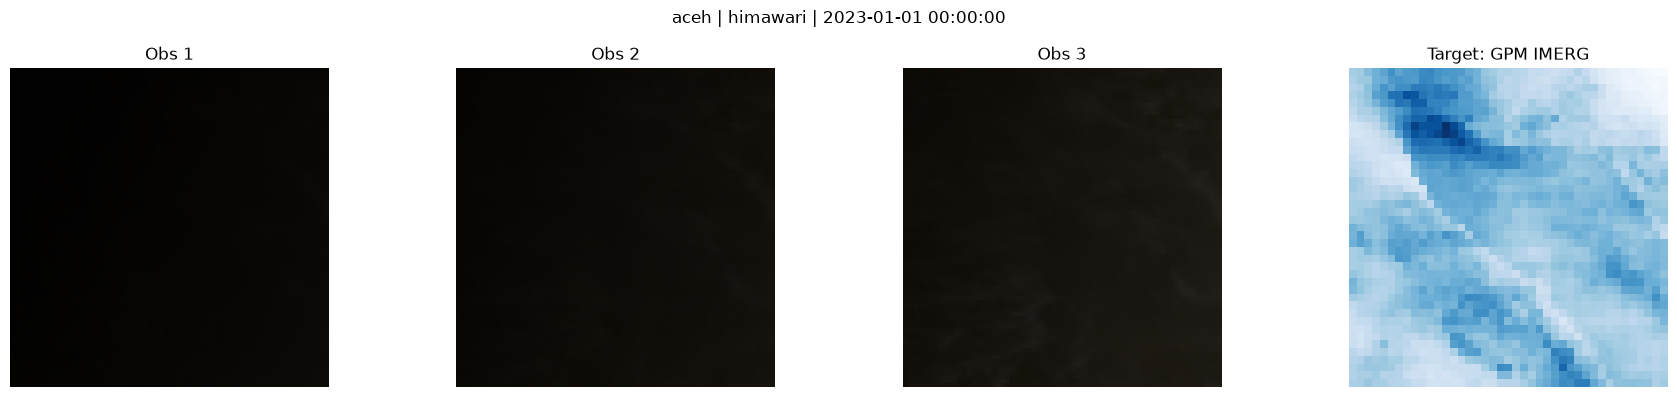

In [7]:
# --- Visualize a Sample ---

sample_row = train_df.iloc[0]
obs_files = ast.literal_eval(sample_row['last_30_minutes_observation_filename'])
target_file = sample_row['gpm_imerg_filename']
sat_type = sample_row['satellite_target']
sat_dir = SATELLITE_DIRS[sat_type]['train']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, obs_name in enumerate(obs_files[:3]):
    with rasterio.open(os.path.join(sat_dir, obs_name)) as src:
        rgb = np.transpose(src.read([1, 2, 3]), (1, 2, 0))
    axes[i].imshow(rgb)
    axes[i].set_title(f'Obs {i+1}')
    axes[i].axis('off')

with rasterio.open(os.path.join(GPM_TRAIN_DIR, target_file)) as src:
    precip = src.read(1)
axes[3].imshow(precip, cmap='Blues')
axes[3].set_title('Target: GPM IMERG')
axes[3].axis('off')

fig.suptitle(f'{sample_row["name_location"]} | {sat_type} | {sample_row["datetime"]}')
plt.tight_layout()
plt.show()

---
## 3. Dataset Class

In [8]:
def parse_observation_filenames(filename_str):
    """Parse the string representation of a list of filenames into a Python list."""
    return ast.literal_eval(filename_str)


class NowcastingDataset(Dataset):
    """PyTorch Dataset for loading satellite observations and GPM IMERG targets.

    Args:
        dataframe: pandas DataFrame with columns from the dataset CSV.
        satellite_dirs: dict mapping satellite name -> directory path,
            e.g. {'himawari': 'train_dataset/himawari', 'meteosat': '...', 'goes': '...'}
        gpm_dir: path to GPM IMERG target TIF directory.
        target_size: (H, W) to resize satellite input to match target.
        num_bands: number of bands to read from each satellite TIF.
        max_obs: maximum number of observation TIFs per sample.
        has_target: if False, skip loading target (for test inference).
    """
    def __init__(self, dataframe, satellite_dirs, gpm_dir, target_size=(41, 41),
                 num_bands=3, max_obs=3, has_target=True):
        self.df = dataframe.reset_index(drop=True)
        self.satellite_dirs = satellite_dirs
        self.gpm_dir = gpm_dir
        self.target_size = target_size
        self.num_bands = num_bands
        self.max_obs = max_obs
        self.has_target = has_target
        self.total_channels = num_bands * max_obs

    def __len__(self):
        return len(self.df)

    def _load_satellite_tif(self, filepath):
        with rasterio.open(filepath) as src:
            data = src.read(list(range(1, self.num_bands + 1))).astype(np.float32)
        return data / 255.0

    def _load_gpm_tif(self, filepath):
        with rasterio.open(filepath) as src:
            data = src.read(1).astype(np.float32)
            nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = 0.0
        return data[np.newaxis, :, :]

    def _resize_bands(self, bands):
        """Resize a (C, H, W) array to target_size. Each observation is resized
        individually to handle varying spatial dimensions across satellites."""
        t = torch.from_numpy(bands).unsqueeze(0)
        t = F.interpolate(t, size=self.target_size, mode='bilinear', align_corners=False)
        return t.squeeze(0).numpy()

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sat_type = row['satellite_target']
        sat_dir = self.satellite_dirs[sat_type]
        obs_files = parse_observation_filenames(row['last_30_minutes_observation_filename'])

        channels = []
        for i in range(self.max_obs):
            if i < len(obs_files):
                fpath = os.path.join(sat_dir, obs_files[i])
                if os.path.exists(fpath):
                    bands = self._load_satellite_tif(fpath)
                    bands = self._resize_bands(bands)
                    channels.append(bands)
                else:
                    channels.append(np.zeros((self.num_bands, *self.target_size), dtype=np.float32))
            else:
                channels.append(np.zeros((self.num_bands, *self.target_size), dtype=np.float32))

        input_tensor = torch.from_numpy(np.concatenate(channels, axis=0))  # (9, 41, 41)

        if self.has_target:
            gpm_path = os.path.join(self.gpm_dir, row['gpm_imerg_filename'])
            target_tensor = torch.from_numpy(self._load_gpm_tif(gpm_path))
        else:
            target_tensor = torch.zeros(1, *self.target_size)

        metadata = {
            'unique_id': row['unique_id'],
            'gpm_imerg_filename': row['gpm_imerg_filename'],
            'satellite_target': sat_type,
            'name_location': row['name_location'],
        }
        return input_tensor, target_tensor, metadata

In [9]:
# --- Quick Test ---

train_sat_dirs = {k: v['train'] for k, v in SATELLITE_DIRS.items()}

ds = NowcastingDataset(train_df.head(5), train_sat_dirs, GPM_TRAIN_DIR)
inp, tgt, meta = ds[0]
print(f'Input:  {inp.shape} (expected [9, 41, 41]),  range [{inp.min():.3f}, {inp.max():.3f}]')
print(f'Target: {tgt.shape} (expected [1, 41, 41]),  range [{tgt.min():.3f}, {tgt.max():.3f}]')
print(f'Meta:   {meta["name_location"]} / {meta["satellite_target"]}')

Input:  torch.Size([9, 41, 41]) (expected [9, 41, 41]),  range [0.004, 0.136]
Target: torch.Size([1, 41, 41]) (expected [1, 41, 41]),  range [0.026, 0.853]
Meta:   aceh / himawari


---
## 4. Train / Validation Split

In [10]:
# Temporal 80/20 split per location to avoid data leakage.

train_df['datetime'] = pd.to_datetime(train_df['datetime'])
train_df = train_df.sort_values(['name_location', 'datetime']).reset_index(drop=True)

trn_dfs, val_dfs = [], []
for loc in train_df['name_location'].unique():
    loc_df = train_df[train_df['name_location'] == loc]
    split_idx = int(len(loc_df) * 0.8)
    trn_dfs.append(loc_df.iloc[:split_idx])
    val_dfs.append(loc_df.iloc[split_idx:])

trn_split = pd.concat(trn_dfs).reset_index(drop=True)
val_split = pd.concat(val_dfs).reset_index(drop=True)

print(f'Train: {len(trn_split):,} samples')
print(f'Val:   {len(val_split):,} samples ({len(val_split)/len(train_df):.0%})')

# Create datasets and loaders
train_dataset = NowcastingDataset(trn_split, train_sat_dirs, GPM_TRAIN_DIR)
val_dataset = NowcastingDataset(val_split, train_sat_dirs, GPM_TRAIN_DIR)

# num_workers=0 is the most reliable setting for Jupyter on macOS.
# Pinned memory only benefits CUDA transfers.
loader_workers = 0 if device.type == 'mps' else 4
pin_memory = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=loader_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=loader_workers, pin_memory=pin_memory)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train: 32,541 samples
Val:   8,145 samples (20%)
Train batches: 2034, Val batches: 510


---
## 5. Model Architecture

A simple fully-convolutional network. All convolutions use `padding=1` to preserve 41×41 spatial dimensions.

```
Input (9, 41, 41)
  → Conv2d(9→32)   + BN + ReLU
  → Conv2d(32→64)  + BN + ReLU
  → Conv2d(64→128) + BN + ReLU
  → Conv2d(128→64) + BN + ReLU
  → Conv2d(64→32)  + BN + ReLU
  → Conv2d(32→1, kernel=1×1)
Output (1, 41, 41)
```

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=9, out_channels=1):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x


model = SimpleCNN(in_channels=INPUT_CHANNELS, out_channels=OUTPUT_CHANNELS).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

# Verify forward pass
dummy = torch.randn(2, INPUT_CHANNELS, *TARGET_SIZE).to(device)
out = model(dummy)
print(f'Forward pass: {dummy.shape} → {out.shape}')

Parameters: 187,905
Forward pass: torch.Size([2, 9, 41, 41]) → torch.Size([2, 1, 41, 41])


---
## 6. Training
- **Loss**: MSE (aligns with the RMSE evaluation metric)
- **Optimizer**: Adam (lr=1e-3)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=3)
- **Checkpointing**: best model saved by validation RMSE

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                                  patience=3)

CHECKPOINT_PATH = os.path.join(MODEL_DIR, 'best_model.pth')
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, 'final_model.pth')

In [13]:
history = {'train_rmse': [], 'val_rmse': [], 'train_loss': [], 'val_loss': [], 'lr': []}
best_val_rmse = float('inf')

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # --- Train ---
    model.train()
    train_losses = []
    for batch_inp, batch_tgt, _ in train_loader:
        batch_inp = batch_inp.to(device)
        batch_tgt = batch_tgt.to(device)

        optimizer.zero_grad()
        predictions = model(batch_inp)
        loss = criterion(predictions, batch_tgt)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)
    train_rmse = np.sqrt(avg_train_loss)

    # --- Validate ---
    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch_inp, batch_tgt, _ in val_loader:
            batch_inp = batch_inp.to(device)
            batch_tgt = batch_tgt.to(device)
            predictions = model(batch_inp)
            loss = criterion(predictions, batch_tgt)
            val_losses.append(loss.item())

    avg_val_loss = np.mean(val_losses)
    val_rmse = np.sqrt(avg_val_loss)

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_rmse'].append(train_rmse)
    history['val_rmse'].append(val_rmse)
    history['lr'].append(current_lr)

    saved_str = ''
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_rmse': val_rmse,
        }, CHECKPOINT_PATH)
        saved_str = ' ★ saved'

    elapsed = time.time() - epoch_start
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f} | '
          f'LR: {current_lr:.2e} | {elapsed:.1f}s{saved_str}')

print(f'\nBest validation RMSE: {best_val_rmse:.4f}')

Epoch 01/20 | Train RMSE: 1.3077 | Val RMSE: 1.6388 | LR: 1.00e-03 | 490.2s ★ saved
Epoch 02/20 | Train RMSE: 1.3029 | Val RMSE: 1.6085 | LR: 1.00e-03 | 507.6s ★ saved
Epoch 03/20 | Train RMSE: 1.2990 | Val RMSE: 1.6019 | LR: 1.00e-03 | 517.1s ★ saved
Epoch 04/20 | Train RMSE: 1.2947 | Val RMSE: 1.5953 | LR: 1.00e-03 | 498.7s ★ saved
Epoch 05/20 | Train RMSE: 1.2902 | Val RMSE: 1.5958 | LR: 1.00e-03 | 483.6s
Epoch 06/20 | Train RMSE: 1.2831 | Val RMSE: 1.5835 | LR: 1.00e-03 | 527.4s ★ saved
Epoch 07/20 | Train RMSE: 1.2773 | Val RMSE: 1.5785 | LR: 1.00e-03 | 507.6s ★ saved
Epoch 08/20 | Train RMSE: 1.2745 | Val RMSE: 1.5961 | LR: 1.00e-03 | 467.3s
Epoch 09/20 | Train RMSE: 1.2722 | Val RMSE: 1.5626 | LR: 1.00e-03 | 476.1s ★ saved
Epoch 10/20 | Train RMSE: 1.2698 | Val RMSE: 1.5727 | LR: 1.00e-03 | 586.6s
Epoch 11/20 | Train RMSE: 1.2669 | Val RMSE: 1.5649 | LR: 1.00e-03 | 523.2s
Epoch 12/20 | Train RMSE: 1.2665 | Val RMSE: 1.5817 | LR: 1.00e-03 | 484.8s
Epoch 13/20 | Train RMSE: 1.2639

KeyboardInterrupt: 

In [ ]:
# --- Plot Training Curves ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS + 1), history['train_rmse'], 'b-o', label='Train RMSE', markersize=4)
axes[0].plot(range(1, EPOCHS + 1), history['val_rmse'], 'r-o', label='Val RMSE', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Training & Validation RMSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, EPOCHS + 1), history['lr'], 'g-o', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Save Final Model ---

torch.save({
    'epoch': EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
}, FINAL_MODEL_PATH)

print(f'Best model:  {CHECKPOINT_PATH}')
print(f'Final model: {FINAL_MODEL_PATH}')
print(f'Best val RMSE: {best_val_rmse:.4f} (epoch {history["val_rmse"].index(best_val_rmse) + 1})')

---
## 7. Inference on Test Data

In [ ]:
# --- Load Best Model ---

model_infer = SimpleCNN(in_channels=INPUT_CHANNELS, out_channels=OUTPUT_CHANNELS).to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model_infer.load_state_dict(checkpoint['model_state_dict'])
model_infer.eval()

print(f'Loaded best model from epoch {checkpoint["epoch"]} (val RMSE: {checkpoint["val_rmse"]:.4f})')

In [ ]:
# --- Build Test Dataset ---

eval_df = pd.read_csv(EVAL_TARGET_CSV)
print(f'Test samples: {len(eval_df):,}')
print(f'Locations: {sorted(eval_df["name_location"].unique())}')
print(f'Satellites: {sorted(eval_df["satellite_target"].unique())}')

test_sat_dirs = {k: v['test'] for k, v in SATELLITE_DIRS.items()}

test_dataset = NowcastingDataset(
    eval_df, test_sat_dirs, gpm_dir=None,
    target_size=TARGET_SIZE, has_target=False
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                         num_workers=4, pin_memory=True)

In [ ]:
# --- Run Inference ---

all_predictions = []

model_infer.eval()
with torch.no_grad():
    for batch_idx, (batch_inp, _, batch_meta) in enumerate(test_loader):
        batch_inp = batch_inp.to(device)
        preds = model_infer(batch_inp).cpu().numpy()

        for i in range(preds.shape[0]):
            meta = {k: v[i] for k, v in batch_meta.items()}
            all_predictions.append((preds[i, 0, :, :], meta))

        if (batch_idx + 1) % 100 == 0:
            print(f'  Processed {(batch_idx + 1) * batch_inp.shape[0]:,} / {len(eval_df):,}')

print(f'Predictions generated: {len(all_predictions):,}')

In [ ]:
# --- Visualize Sample Predictions ---

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
sample_indices = np.linspace(0, len(all_predictions) - 1, 10, dtype=int)

for ax_idx, sample_idx in enumerate(sample_indices):
    pred, meta = all_predictions[sample_idx]
    row, col = ax_idx // 5, ax_idx % 5
    axes[row, col].imshow(pred, cmap='Blues', vmin=0)
    axes[row, col].set_title(f'{meta["name_location"]}\n{meta["unique_id"]}', fontsize=8)
    axes[row, col].axis('off')

plt.suptitle('Sample Predictions', fontsize=14)
plt.tight_layout()
plt.show()

pred_values = np.array([p[0] for p in all_predictions])
print(f'Prediction stats: min={pred_values.min():.4f}, max={pred_values.max():.4f}, '
      f'mean={pred_values.mean():.4f}')

---
## 8. Generate Submission

The submission ZIP must have this structure:
```
submission.zip
├── evaluation_target.csv
└── test_files/
    ├── test_location_GPM_IMERG_YYYY-MM-DD_HH-MM-SS.tif
    └── ...
```

In [ ]:
# --- Save Predictions as GeoTIFF ---

SUBMISSION_DIR = 'submission'
SUBMISSION_TEST_FILES = os.path.join(SUBMISSION_DIR, 'test_files')
SUBMISSION_ZIP = 'submission.zip'

if os.path.exists(SUBMISSION_TEST_FILES):
    shutil.rmtree(SUBMISSION_TEST_FILES)
os.makedirs(SUBMISSION_TEST_FILES, exist_ok=True)

for pred_array, meta in all_predictions:
    out_path = os.path.join(SUBMISSION_TEST_FILES, meta['gpm_imerg_filename'])
    with rasterio.open(
        out_path, 'w', driver='GTiff',
        height=pred_array.shape[0], width=pred_array.shape[1],
        count=1, dtype='float32',
    ) as dst:
        dst.write(pred_array.astype(np.float32), 1)

saved_files = os.listdir(SUBMISSION_TEST_FILES)
print(f'Saved {len(saved_files):,} prediction TIFs')

# Spot-check
with rasterio.open(os.path.join(SUBMISSION_TEST_FILES, saved_files[0])) as src:
    print(f'  Sample: {src.width}×{src.height}, bands={src.count}, dtype={src.dtypes[0]}')

In [ ]:
# --- Create Submission CSV ---

submission_rows = [{'unique_id': m['unique_id'], 'gpm_imerg_filename': m['gpm_imerg_filename']}
                   for _, m in all_predictions]
submission_df = pd.DataFrame(submission_rows)
submission_csv_path = os.path.join(SUBMISSION_DIR, 'evaluation_target.csv')
submission_df.to_csv(submission_csv_path, index=False)

print(f'Submission CSV: {len(submission_df):,} rows')
print(f'Unique IDs: {submission_df["unique_id"].nunique():,} (expected: {len(eval_df):,})')

In [ ]:
# --- Package ZIP ---

if os.path.exists(SUBMISSION_ZIP):
    os.remove(SUBMISSION_ZIP)

with zipfile.ZipFile(SUBMISSION_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(submission_csv_path, 'evaluation_target.csv')
    for fname in sorted(os.listdir(SUBMISSION_TEST_FILES)):
        zf.write(os.path.join(SUBMISSION_TEST_FILES, fname), os.path.join('test_files', fname))

zip_size_mb = os.path.getsize(SUBMISSION_ZIP) / (1024 * 1024)
print(f'Created: {SUBMISSION_ZIP} ({zip_size_mb:.1f} MB)')

with zipfile.ZipFile(SUBMISSION_ZIP, 'r') as zf:
    print(f'Files in ZIP: {len(zf.namelist()):,}')

In [ ]:
# --- Validate Submission ---

print('=== Submission Validation ===')
errors = []

# 1. CSV exists
if not os.path.exists(submission_csv_path):
    errors.append('Missing evaluation_target.csv')
else:
    print('✓ evaluation_target.csv exists')

# 2. Required columns
sub_df = pd.read_csv(submission_csv_path)
required_cols = {'unique_id', 'gpm_imerg_filename'}
if not required_cols.issubset(set(sub_df.columns)):
    errors.append(f'Missing columns: {required_cols - set(sub_df.columns)}')
else:
    print('✓ Required columns present')

# 3. No nulls
if sub_df[['unique_id', 'gpm_imerg_filename']].isnull().any().any():
    errors.append('Null values found')
else:
    print('✓ No null values')

# 4. All unique_ids present
required_ids = set(eval_df['unique_id'])
submitted_ids = set(sub_df['unique_id'])
missing_ids = required_ids - submitted_ids
if missing_ids:
    errors.append(f'Missing {len(missing_ids)} unique_ids')
else:
    print(f'✓ All {len(required_ids):,} unique_ids present')

# 5. No duplicates
if sub_df['unique_id'].duplicated().any():
    errors.append('Duplicate unique_ids')
else:
    print('✓ No duplicate unique_ids')

# 6. All TIF files exist and are readable
missing_tifs = []
for _, row in sub_df.iterrows():
    fpath = os.path.join(SUBMISSION_TEST_FILES, row['gpm_imerg_filename'])
    if not os.path.exists(fpath):
        missing_tifs.append(row['gpm_imerg_filename'])
if missing_tifs:
    errors.append(f'{len(missing_tifs)} TIF files missing')
else:
    print(f'✓ All {len(sub_df):,} TIF files present')

# 7. Dimensions check
sample_pred = os.path.join(SUBMISSION_TEST_FILES, os.listdir(SUBMISSION_TEST_FILES)[0])
with rasterio.open(sample_pred) as src:
    if (src.width, src.height) != TARGET_SIZE:
        errors.append(f'Dimension mismatch: {src.width}×{src.height} vs {TARGET_SIZE}')
    else:
        print(f'✓ Dimensions correct ({src.width}×{src.height})')

if errors:
    print(f'\n✗ FAILED ({len(errors)} errors):')
    for e in errors:
        print(f'  - {e}')
else:
    print(f'\n✓ ALL CHECKS PASSED — ready for upload!')